# Subspace Estimation and MUSIC in Multi-Target Scenario
This notebook will introduce you the *MUltiple SIgnal Classification* (MUSIC) algorithm, a very common and simple algorithm used in the DoA estimation problem, along with discussing the covariance matrix in more detail. Meanwhile, we will also implement different data models. 

In [ ]:
# Importing modules
import numpy as np; 
import matplotlib.pyplot as plt; 

# np.random.seed(42); # In order to ensure reproducibility. You can use different seed values.

## Data Model
As always, let's get a quick refresher on the several variables we use to build our synthetic dataset.

* Antenna position matrix $\mathbf{P} \in \mathbb{R}^{3 \times N}$ holds the values for the position of the $n^{th}$ antenna element with respect to the origin point in meters.

$$
\mathbf{p}_{n} = [p_{n,x} \hat{\mathbf{x}}, p_{n,y} \hat{\mathbf{y}}, p_{n,z} \hat{\mathbf{z}}]^{T} \in \mathbb{R}^{3 \times 1}
\\
\mathbf{P} = [\mathbf{p}_{1}, ..., \mathbf{p}_{N}] \in \mathbb{R}^{3 \times N}
$$

* Target angle vector $\mathbf{\omega}_{k} \in \mathbb{R}^{3 \times 1}$ is the 3D Cartesian coordinate expression of the $k^{th}$ target's azimuth ($\phi_k$) and elevation ($\theta_k$) angles.

$$
\mathbf{\omega}_{k} = [sin(\theta_k)cos(\phi_k), sin(\theta_k)sin(\phi_k), cos(\phi_k)]^T \in \mathbb{R}^{3 \times 1}
$$

* The derivative of the target angle vector with respect to the elevation angle $\frac{\partial \mathbf{\omega}_{k}}{\partial \theta_{k}} \in \mathbb{R}^{3 \times 1}$ is used to calculate the derivate of the steering vector.

$$
\frac{\partial \mathbf{\omega}_{k}}{\partial \theta_{k}} = [cos(\theta_k)cos(\phi_k), cos(\theta_k)sin(\phi_k), -sin(\phi_k)]^T \in \mathbb{R}^{3 \times 1}
$$

We are going to use the derivative of the steering vector soon for the calculation of the absolute error that we cannot beat no matter what, and we will talk about this bound and why it is such an immovable object in a later notebook.

In [2]:
# Defining methods
hermitian = lambda array: np.conj(array).T; 


def steering_vector(
    sensor_pos: np.ndarray,
    ang_elev: float,
    ang_azim: float,
    wavelen: float
    ) -> np.ndarray:
  omega = np.array([[np.sin(ang_elev)*np.cos(ang_azim)],
                    [np.sin(ang_elev)*np.sin(ang_azim)],
                    [np.cos(ang_elev)]]);
  return np.exp(1j*2*np.pi/wavelen*sensor_pos.T@omega); 

def d_steering_vector(
    sensor_pos: np.ndarray,
    ang_elev: float,
    ang_azim: float,
    wavelen: float
    ) -> np.ndarray:
  a = steering_vector(sensor_pos, ang_elev, ang_azim, wavelen);
  d_omega = np.array([[np.cos(ang_elev)*np.cos(ang_azim)],
                      [np.cos(ang_elev)*np.sin(ang_azim)],
                      [-np.sin(ang_elev)]]);
  return -1j*2*np.pi/wavelen * a * sensor_pos.T@d_omega; 


def generate_pos_1d_ula(
    N: int,
    d: float,
    axis=(1.,0.,0.),
    x_init=(0.,0.,0.)
    ) -> np.ndarray:
  if len(axis) != 3:
    raise TypeError(f"""The axis argument represents a 3D Cartesian vector.
      The length of the input ({len(axis)}) does not match with expected
      size 3.""")
  if sum(axis) != 1:
    axis_new = (x/sum(axis) for x in axis); 
    axis = axis_new; 

  if len(x_init) != 3:
    raise TypeError(f"""The x_init argument represents a 3D cartesian vector.
      The length of the input ({len(x_init)}) does not match with expected
      size 3."""); 

  sensor_pos = np.tile(x_init, N).reshape(N,3).T \
    + (np.arange(0,N,1)*d) * np.tile(np.array(axis), N).reshape(N,3).T; 
  return sensor_pos; 


def generate_random_targets(ang_min: float, ang_max: float, ang_dist: float, K: int) -> np.ndarray:
  """
  Generate K uniformly random target angles between ang_min and ang_max with a minimum separation angle of ang_dist.

  --Inputs--
  ang_min: Minimum angle in degrees. Type of float.
  ang_max: Maximum angle in degrees. Type of float.
  ang_dist: Minimum separation angle in degrees. Type of float.
  K: Number of target angles. Type of int.

  --Output--
  angs: K uniformly random angles. Type of np.ndarray of size (K,) and dtype of np.float64.
  """
  while True:
    angs = np.random.uniform(ang_min, ang_max, K); 
    angs_sort = np.sort(angs); 
    for i in range(K-1):  # break for if is not valid
      is_valid = np.abs(angs_sort[i+1] - angs_sort[i]) >= ang_dist; 
      if not is_valid:
        break; 
    if is_valid: break;   # break while if is valid
  return angs; 

## Current Benchmarks: DAS and MVDR

Since we already have the implementation of DAS (Bartlett) and MVDR (Capon) beamforming algorithms, we can wrap them in a method and call them in comparison with MUSIC. As we move further, we will continue including comparing the performance of different algorithms.

Confused with the names? Where is DAS? What is Capon? Go back to the [previous notebook](https://colab.research.google.com/github/i-JRay-i/doa_estimation_tutorial/blob/master/doa_01_bartlett_capon.ipynb) and take your refresher!

In [3]:
def doa_est_bartlett(
    theta_scan: np.ndarray,
    sensor_pos: np.ndarray,
    R_xx: np.ndarray,
    wl: float) -> np.ndarray:
  """
  Generates the Bartlett power pseudospectrum for a given scan angle range. 

  --Inputs--
  theta_scan: Elevation angle scan array in degrees. Type of np.ndarray of size (N,1) and dtype np.float64.
  sensor_pos: Antenna array sensor positions in 3D Cartesian coordinates. Type of np.ndarray of size (3,N) and dtype np.float64.
  R_xx: Signal covariance matrix. Type of np.ndarray of size (N,N) and dtype np.complex128.
  wl: Signal of interest wavelength. Type of float. 

  --Output--
  P_bartlett: Bartlett pseudospectrum. Type of np.ndarray of size (N,1) and dtype np.float64.
  """
  P_bartlett = np.zeros(len(theta_scan), dtype=np.complex128); 

  for i, theta in enumerate(theta_scan):
    bartlett = steering_vector(sensor_pos, np.deg2rad(theta), np.deg2rad(0), wl); 
    P_bartlett[i] = np.squeeze(hermitian(bartlett) @ R_xx @ bartlett); 

  return P_bartlett; 


def doa_est_capon(
    theta_scan: np.ndarray,
    sensor_pos: np.ndarray,
    R_xx: np.ndarray,
    wl: float) -> np.ndarray:
  """
  Generates the Capon (MVDR) power pseudospectrum for a given scan angle range. 

  --Inputs--
  theta_scan: Elevation angle scan array in degrees. Type of np.ndarray of size (N,1) and dtype np.float64.
  sensor_pos: Antenna array sensor positions in 3D Cartesian coordinates. Type of np.ndarray of size (3,N) and dtype np.float64.
  R_xx: Signal covariance matrix. Type of np.ndarray of size (N,N) and dtype np.complex128.
  wl: Signal of interest wavelength. Type of float. 

  --Output--
  P_capon: Capon pseudospectrum. Type of np.ndarray of size (N,1) and dtype np.float64.
  """
  Rxx_inv = np.linalg.inv(R_xx); 
  P_capon = np.zeros(len(theta_scan), dtype=np.complex128); 

  for i, theta in enumerate(theta_scan):
    bartlett = steering_vector(sensor_pos, np.deg2rad(theta), np.deg2rad(0), wl); 
    capon = (Rxx_inv @ bartlett) / (hermitian(bartlett) @ Rxx_inv @ bartlett); 
    P_capon[i] = np.squeeze(hermitian(capon) @ R_xx @ capon); 

  return P_capon; 

## Parameters
* $c$: Speed of light. In this example, assumed to be rounded to $30*10^8\text{ m/s}$.
* $f$: Frequency of the target signals in Herz. For this example, we will use $5\text{ GHz}$
* $\lambda$: Wavelength of the target signals in meters. It is calculated by the classical formula: $\lambda = \frac{c}{f}$, which gives $6\text{ cm}$ in our case.

Next step is to determine the ULA parameters.

* $N$: # of antenna elements. We can choose this value as $16$.
* $T$: # of snapshots. MUSIC is an algorithm that benefits high number of snapshots in order to average the sample covariance matrix to the true one as much as possible, therefore we went with a rather big number of $4000$. You can always change and see its effect on the estimation after giving this value a try first.
* $K$: # of targets. For an easy case, let's keep the number of targets at $3$.

In [4]:
# Defining parameters
c = 3*1e8;      # The speed of light in vacuum (m/s)
f_c = 5*1e9;    # Target carrier frequency (Hz)
f_s = 100*1e9;  # Receiver sampling frequency (Hz)
wl = c/f_c;     # Signal wavelenght (m)
d = wl/2;       # Antenna distance (m)

N = 16;         # Number of antennas
T = 4000;       # Number of snapshots
K = 3;          # Number of targets

S_db = [0]*K;   # Target signal power (dB)
snr_db = 10.0;  # Signal-to-Noise Ratio (dB)

ang_azim = 0;   # Azimuth angle (deg)
ang_min = -60;  # Minimum elevation angle (deg)
ang_max = 60;   # Maximum elevation angle (deg)
ang_dist = 5;   # Minimum distance between targets (deg)
ang_res = 0.1   # Angular resolution in scanning (deg)

sensor_pos = generate_pos_1d_ula(N, d);                                 # Sensor position
theta_scan = np.arange(-90,90+ang_res,ang_res);                         # Angle scan
true_angles = generate_random_targets(ang_min, ang_max, ang_dist, K);   # Target elevation angles

for k in range(K):
  print(f"Target {k} True Angle: {true_angles[k]:.3f}°"); 

Target 0 True Angle: -53.840°
Target 1 True Angle: -23.527°
Target 2 True Angle: 4.271°


## Signal Generation
We will use the narrowband far-field model with Rayleigh fading to make our life as easy as possible (refer to the [first notebook](https://colab.research.google.com/github/i-JRay-i/doa_estimation_tutorial/blob/master/doa_00_signal_model.ipynb) if none of these terms makes sense to you).

In [5]:
A = np.column_stack([steering_vector(sensor_pos, np.deg2rad(theta), np.deg2rad(0), wl) for theta in true_angles]); # Array Steering Matrix

# Data Generation
S_amp = np.diag([np.sqrt(10**(s_db / 10)) for s_db in S_db]); 
S = S_amp @ (np.random.randn(K, T) + 1j*np.random.randn(K, T))/np.sqrt(2); # Target Signals: Uncorrelated Gaussian (variance = 1.0)

# Noise: Spatially white complex Gaussian noise
noise_pow = 10**(-snr_db/10); 
Noise = np.sqrt(noise_pow) * (np.random.randn(N, T) + 1j*np.random.randn(N, T))/np.sqrt(2); 

# Received Signal at the Array
X = A @ S + Noise; 

## Calculating the Cramér-Rao Lower Bound (CRLB)

We will mention the [Cramér-Rao Lower Bound](https://en.wikipedia.org/wiki/Cram%C3%A9r%E2%80%93Rao_bound) (CRLB) in an upcoming notebook, however for now you can understand this concept with a pastry-sounding name as the absolute lower bound of error we can reach regardless of any estimation algorithm we use. Not so appetizing implications for such a delicious name, I know. CRLB has its roots in the field of information theory, if you are so impatient to wait for its time, you can look at some resources in the links below.

On YouTube: [The Fisher Information](https://www.youtube.com/watch?v=pneluWj-U-o) by Mutual Information gives the essential information for understanding the Fisher Information Matrix (FIM), which is used to construct the Cramer-Rao Lower Bound, and [Maximum Likelihood - Cramer Rao Lower Bound Intuition](https://www.youtube.com/watch?v=i0JiSddCXMM) by Ben Lambert gets into the intuition behind the CRLB.

The CRLB formula we are using here is based on the paper [here](https://ieeexplore.ieee.org/abstract/document/17564)

In [6]:
def calculate_crb(
    sensor_pos: np.ndarray, 
    N: int, 
    T: int, 
    wl: float, 
    angs_elev: np.ndarray, 
    snr_db: float, 
    S_db: list) -> np.ndarray:
  """
  Calculates the stochastic Cramer-Rao Lower Bound (CRLB) for a given sensor
  array and number of targets.
  """
  noise_pow = 10**(-snr_db/10); 
  sig_pow = [10**(s_db)/10 for s_db in S_db]; 
  R_ss = np.diag(np.array(sig_pow)); 

  K = angs_elev.shape[0]; 

  # Steering matrix (A_mat) Derivative matrix (D_mat) of steering vectors w.r.t angles (in degrees)
  A_mat = np.zeros((N, K), dtype=complex); 
  D_mat = np.zeros((N, K), dtype=complex); 

  for i, theta in enumerate(angs_elev):
    A_mat[:,i] = steering_vector(sensor_pos, np.deg2rad(theta), np.deg2rad(0), wl)[:,0];
    D_mat[:,i] = d_steering_vector(sensor_pos, np.deg2rad(theta), np.deg2rad(0), wl)[:,0];

  Rxx_true = A_mat@R_ss@A_mat.conj().T + noise_pow*np.eye(N); 
  Rxx_inv = np.linalg.inv(Rxx_true);

  P_A_perp = np.eye(N) - A_mat@np.linalg.inv(A_mat.conj().T@A_mat)@A_mat.conj().T; # Projection matrix onto the noise subspace

  # The Fisher Information Matrix components
  term1 = D_mat.conj().T @ P_A_perp @ D_mat; 
  term2 = (R_ss @ A_mat.conj().T @ Rxx_inv @ A_mat @ R_ss).T; 

  FIM = (2*T/noise_pow) * np.real(term1 * term2); 

  return np.linalg.inv(FIM); 


In [7]:
## Cramer-Rao Bound
CRB_mat = calculate_crb(sensor_pos, N, T, wl, true_angles, snr_db, S_db); 
CRB_var = np.diag(CRB_mat);       # The diagonal elements are the minimum variances for target 1 and target 2
CRB_rmse = np.sqrt(CRB_var);      # Convert variance (deg^2) to Standard Deviation / RMSE (deg)

## The MUSIC Algorithm

We will begin by reminding the definition of the true sample covariance matrix $\mathbf{R}_{xx}$, which is the estimated value of the autocorrelation matrix of the signal $\mathbf{X}$. 

$$\mathbf{R}_{xx} = E[\mathbf{X}\mathbf{X}^H]$$

Also remember that we do not have this matrix, instead we have an approximation of it in the form of the sample covariance matrix, i.e. averaged sum of the autocorrelation matrix of each snapshot.

$$\hat{\mathbf{R}}_{xx} = \frac{1}{T} \sum_{t=1}^{T} \mathbf{x}(t)\mathbf{x}^H(t)$$

Next, we perform an [*Eigenvalue Decomposition*](https://en.wikipedia.org/wiki/Eigendecomposition_of_a_matrix) (EVD) on $\hat{\mathbf{R}}_{xx}$. This breaks the matrix down into its fundamental structural components: *eigenvalues* (which represent power) and *eigenvectors* (which represent spatial directions).

$$\hat{\mathbf{R}}_{xx} = \mathbf{U}\boldsymbol{\Sigma}\mathbf{U}^H$$

For an array of $N$ sensors and $K$ uncorrelated targets, we simply sort the eigenvalues from largest to smallest. The $K$ largest eigenvalues correspond to the target signals and their matching eigenvectors span the *signal subspace* ($\mathbf{U}_s$). The remaining $N - K$ smallest eigenvalues correspond to the background noise and their matching eigenvectors span the *noise subspace* ($\mathbf{U}_n$). Because these eigenvectors are orthogonal to each other, the true signal steering vectors $\mathbf{a}(\theta)$ are mathematically orthogonal to the noise subspace $\mathbf{U}_n$. Therefore, for a true target angle $\theta$:

$$\mathbf{a}^H(\theta)\mathbf{U}_n = 0$$

In reality, because of finite data samples and fading, that product won't be exactly zero, but it will be incredibly small. This is something that we \*actually\* kind of want, because MUSIC defines a pseudospectrum equation to turn this value into a peak-finding problem:

$$P_{\text{MUSIC}}(\theta) = \frac{1}{\mathbf{a}^H(\theta)\mathbf{U}_n\mathbf{U}_n^H\mathbf{a}(\theta)}$$

and having a non-zero divider below provides stability by preventing division-by-zero. We can still add a small stabilizer constant to completely prevent offshooting. Regardless, this is the basic form of MUSIC.

In [8]:
# The MUSIC Algorithm
Rxx_samp = (X @ X.conj().T)/T;        # Sample (estimated) covariance
_, eigenvectors = np.linalg.eigh(Rxx_samp); 
Un = eigenvectors[:, :-K];            # Noise space

### Eigenvalues
Why do we assume that the signal space is associated with the largest eigenvalues? What is the intuition behind the relation between eigenvalues and target signals? That was a very serious question I had when I first jumped into MUSIC; although the algorithm is very simple to implement, its logic is in fact much more fundamental to establish anything else that came after it.

The connection exists because the signal eigenvectors and the target steering vectors span the exact same mathematical subspace. If you remember what eigenvectors basically are, you can intuitively understand the reasoning behind this assumption. The short answer is: eigenvalues represent **power**. 

If you look at a covariance matrix through the lens of statistics, the eigenvalues measure the variance (power) of the data along the direction of their corresponding eigenvectors. Because target signals inject physical energy into the system, the directions in space where those signals are present will naturally have much higher energy than the directions containing only background static noise.

To see this mathematically, let's look at what actually makes up the covariance matrix $R_{xx}$ when $K$ signals hit an array of $M$ antennas. Assuming the background noise is white and uncorrelated, the matrix breaks down perfectly into two parts:

$$\mathbf{R}_{xx} = \mathbf{A}\mathbf{R}_{ss}\mathbf{A}^H + \sigma_{n}^2\mathbf{I}_N$$

* $\mathbf{A}\mathbf{R}_{ss}\mathbf{A}^H$ - **The Signal Component**: $\mathbf{A} = [\mathbf{a}(\theta_1), \mathbf{a}(\theta_2), \dots, \mathbf{a}(\theta_D)]$ is the $K \times K$ array steering matrix containing the true target steering vectors, and $\mathbf{R}_{ss}$ is the $K \times K$ source covariance matrix. This component only has a rank of $K$; it is entirely confined to a $K$-dimensional slice of space.

* $\sigma_{n}^2\mathbf{I}_N$ - **The Noise Component**: $\sigma_{n}^2$ is the noise *variance* (power), $I_{N}$ is the identity matrix of size $N$, and the multiplication $\sigma^2\mathbf{I}_N$ represents the white noise power across the sensors. This baiscally tells that the noise injects exactly $\sigma^2$ amount of power equally in every single direction across the entire $N$-dimensional space.

From this model, we can derive a couple of points

1. **The noise is isotropic.** The background ambient hiss identical everywhere; it forms a perfect sphere of low energy with a radius of $\sigma_{n}^2$. If you perform EVD on just the noise, all the eigenvalues would be exactly equal to $\sigma_{n}^2$.
2. **The signals add plugs of energy.** All $K$ targets are standing in specific spots. Their strengths $[\sigma_{1}, \dots, \sigma_{K}]$ for $k \in {1,K}$ inject a certain amount of additional directional energy into the channel. The sphere stretching out in their specific directions morphs into a dramatic ellipsoid. 

When you perform EVD on the combined matrix $R_{xx}$, the math separates the total energy into orthogonal directions. In the $K$ directions of the signals, the total power is the target power plus the background noise power. 

$$\lambda_{\text{signal}} = \sigma_{k}^2 + \sigma_{n}^2$$

In the remaining $M-K$ directions, there are no signals present. The only energy available is the baseline background hiss.

$$\lambda_{\text{noise}} = \sigma_{n}^2$$

Because physical signal power is always positive, it is a mathematical guarantee that:

$$\lambda_{\text{signal}} > \lambda_{\text{noise}}$$

When you sort the eigenvalues from largest to smallest, you are sorting the spatial directions from "loudest" to "quietest":

$$
\underbrace{\lambda_1 \ge \lambda_2 \ge \dots \ge \lambda_K}_{\text{Signal Subspace (Signal + Noise)}} > \underbrace{\lambda_{K+1} = \dots = \lambda_M = \sigma^2}_{\text{Noise Subspace (Pure Noise)}}
$$

This is why we confidently grab the eigenvectors corresponding to the top $K$ largest eigenvalues to build our signal subspace for ESPRIT, or throw them away to use the remaining orthogonal noise eigenvectors for MUSIC.

### Derivation
Ok, so we established the role eigenvalues play in determining target signals' strength. We were also reminded that the eigenvectors are orthogonal to each other. However, it says nothing about the orthogonality of steering vectors $\mathbf{a}(\theta)$ with respect to the noise subspace $\mathbf{U}_{n}$ by default. So, how can we be sure that the equation above holds, upon which MUSIC algorithm was established? 

The connection exists because the signal eigenvectors and the target steering vectors span the exact same mathematical subspace. Here is the step-by-step mathematical demonstration of how this relation is established and why orthogonality is guaranteed.

When you perform EVD on $\mathbf{R}_{xx}$, you are finding eigenvectors $\mathbf{e}_i$ and eigenvalues $\lambda_i$ that satisfy:

$$\mathbf{R}_{xx}\mathbf{e}_i = \lambda_i\mathbf{e}_i$$

Substitute the definition of $\mathbf{R}_{xx}$ into this equation, we get:

$$(\mathbf{A}\mathbf{R}_{ss}\mathbf{A}^H + \sigma^2\mathbf{I}_M)\mathbf{e}_i = \lambda_i\mathbf{e}_i$$

$$\mathbf{A}\mathbf{R}_{ss}\mathbf{A}^H\mathbf{e}_i + \sigma^2\mathbf{e}_i = \lambda_i\mathbf{e}_i$$

$$\mathbf{A}(\mathbf{R}_{ss}\mathbf{A}^H\mathbf{e}_i) = (\lambda_i - \sigma^2)\mathbf{e}_i$$

When you look closely at the left side of that final equation, you will see that the matrix $\mathbf{A}$ multiplied by a vector vector $(\mathbf{R}_{ss}\mathbf{A}^H\mathbf{e}_i)$. By definition, any matrix-vector multiplication result must lie within the column space (span) of that matrix. Therefore, for any eigenvector where $\lambda_i \neq \sigma^2$ (which are the $D$ signal eigenvectors $\mathbf{U}_s$), the eigenvector $\mathbf{e}_i$ must be a linear combination of the columns of $\mathbf{A}$.

$$\text{span}(\mathbf{U}_{s}) = \text{span}(\mathbf{A})$$

The signal eigenvectors do not equal the steering vectors, but they map out the exact same geometric hyperplane. Now, what happens to the remaining $N-K$ eigenvectors, which belong to the noise subspace ($\mathbf{U}_n$)? For these components, there is no signal power, so their eigenvalues are purely the noise floor: $\lambda_i = \sigma_{n}^2$. When we plug this result into our derivation, we get:

$$\mathbf{A}(\mathbf{R}_{ss}\mathbf{A}^H\mathbf{e}_i) = (\sigma^2 - \sigma^2)\mathbf{e}_{i} = 0$$


Just multiply both sides from the left by the conjugate transpose of the eigenvector ($\mathbf{e}_i^H$) to see clearly what this implies:

$$
\begin{aligned}
\mathbf{e}_i^H\mathbf{A}\mathbf{R}_{ss}\mathbf{A}^H\mathbf{e}_{i} &= 0
\\
(\mathbf{A}^H\mathbf{e}_i)^H \mathbf{R}_{ss} (\mathbf{A}^H\mathbf{e}_{i}) &= 0
\end{aligned}
$$

As long as the target signals are uncorrelated (or only partially correlated), the source covariance matrix $\mathbf{R}_{ss}$ is positive definite (full rank). In linear algebra, the only way a quadratic form $\mathbf{v}^H\mathbf{R}\mathbf{v} = 0$ when $\mathbf{R}$ is positive definite is if the vector $\mathbf{v}$ itself is exactly zero. Therefore:

$$\mathbf{A}^H\mathbf{e}_{i} = 0 \quad \text{for all } \mathbf{e}_{i} \in \mathbf{U}_{n}$$

Because $\mathbf{A}$ is comprised of your individual target steering vectors $[\mathbf{a}(\theta_1), \dots, \mathbf{a}(\theta_D)]$, this explicitly proves that:

$$\mathbf{a}^H(\theta_d)\mathbf{e}_{i} = 0$$

Now it is obvious why the condition of **uncorrelated targets** is so vital. If two targets are perfectly coherent $\mathbf{R}_{ss}$ loses rank, when it is no longer positive definite the quadratic form fails, and the steering vectors are no longer guaranteed to be orthogonal to the noise subspace.

In [9]:
P_music = np.zeros(len(theta_scan)); 

# Creating the MUSIC pseudospectrum
for i, theta in enumerate(theta_scan):
    a_theta = steering_vector(sensor_pos, np.deg2rad(theta), np.deg2rad(0), wl); 
    denominator = np.abs(a_theta.conj().T @ Un @ Un.conj().T @ a_theta); 
    P_music[i] = 1 / np.squeeze(denominator); 

P_music_dB = 10 * np.log10(P_music / np.max(P_music)); 

In [10]:
# Printing the results
print("\nTheoretical Performance Limits (Stochastic CRB)");
for i in range(K):
    print(f"Target {i+1} ({true_angles[i]:.2f}°): Minimum RMSE Error = {CRB_rmse[i]:.5f}"); 


Theoretical Performance Limits (Stochastic CRB)
Target 1 (-53.84°): Minimum RMSE Error = 0.00034
Target 2 (-23.53°): Minimum RMSE Error = 0.00022
Target 3 (4.27°): Minimum RMSE Error = 0.00020


We will also run DAS and MVDR methods for comparing their performance with MUSIC.

In [11]:
# Running the compared algorithms (DAS and MVDR)
P_bartlett = doa_est_bartlett(theta_scan, sensor_pos, Rxx_samp, wl); 
P_bartlett_dB = 10*np.log10(np.abs(np.multiply(P_bartlett/np.amax(P_bartlett), np.conjugate(P_bartlett/np.amax(P_bartlett))))); 

P_capon = doa_est_capon(theta_scan, sensor_pos, Rxx_samp, wl); 
P_capon_dB = 10*np.log10(np.abs(np.multiply(P_capon/np.amax(P_capon), np.conjugate(P_capon/np.amax(P_capon))))); 

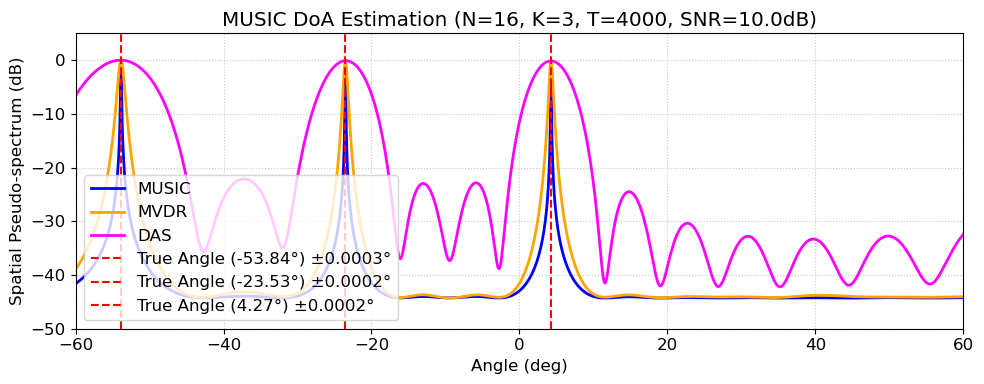

In [12]:
# Visualization
plt.rcParams.update({'font.size': 12}); 

plt.figure(figsize=(10, 4)); 
plt.plot(theta_scan, P_music_dB, linewidth=2, color='blue', label='MUSIC'); 
plt.plot(theta_scan, P_capon_dB, linewidth=2, color='orange', label='MVDR'); 
plt.plot(theta_scan, P_bartlett_dB, linewidth=2, color='magenta', label='DAS'); 

for i, angle in enumerate(true_angles):
    plt.axvline(x=angle, color='red', linestyle='--',
                label=f'True Angle ({angle:.2f}°) ±{CRB_rmse[i]:.4f}°'); 

plt.title(f'MUSIC DoA Estimation (N={N}, K={K}, T={T}, SNR={snr_db}dB)'); 
plt.xlabel('Angle (deg)'); 
plt.ylabel('Spatial Pseudo-spectrum (dB)'); 
plt.xlim([ang_min, ang_max]); 
plt.ylim([-50, 5]); 
plt.grid(True, linestyle=':', alpha=0.7); 

handles, labels = plt.gca().get_legend_handles_labels(); 
by_label = dict(zip(labels, handles)); 
plt.legend(by_label.values(), by_label.keys(), loc="lower left"); 

plt.tight_layout(); 
plt.show(); 

## MUSIC with Alternative Target Scenarios.

Look at the sharp responses; even sharper than MVDR. It is a music to our ears (pun very much intended)! Because of its simplicity to implement, MUSIC today is one of the most common algorithms found in many applications, even despite its raw data requirement, and the signal conditions usually hold fine for MUSIC to perform well. 

What if it doesn't? We shall start using a few other data models to explore what exactly happens when we do not have the perfedct data. Let's first wrap our MUSIC algorithm into its own method for the ease of use.

In [13]:
# Wrapping MUSIC into its own method
def doa_est_music(
      theta_scan: np.ndarray, 
      sensor_pos:  np.ndarray, 
      R_xx: np.ndarray, 
      wl: float, 
      K: int):
    """
  Generates the MUSIC power pseudospectrum for a given scan angle range. 

  --Inputs--
  theta_scan: Elevation angle scan array in degrees. Type of np.ndarray of size (N,1) and dtype np.float64.
  sensor_pos: Antenna array sensor positions in 3D Cartesian coordinates. Type of np.ndarray of size (3,N) and dtype np.float64.
  R_xx: Signal covariance matrix. Type of np.ndarray of size (N,N) and dtype np.complex128.
  wl: Signal of interest wavelength. Type of float. 
  K: Number of targets. Type of int.

  --Output--
  P_music: The MUSIC pseudospectrum. Type of np.ndarray of size (N,1) and dtype np.float64.
    """
    _, e_vec = np.linalg.eigh(R_xx); 
    Un = e_vec[:, :-K]; 

    P_music = np.zeros(len(theta_scan), dtype=np.float64); 

    for i, theta in enumerate(theta_scan):
        a_theta = steering_vector(sensor_pos, np.deg2rad(theta), np.deg2rad(0), wl); 
        denominator = np.abs(a_theta.conj().T @ Un @ Un.conj().T @ a_theta); 
        P_music[i] = 1 / np.squeeze(denominator); 

    return P_music; 

### MUSIC with Low Snapshot

Let's start with the case for low snapshot numbers. In the example below, we reduced the number snapshots all the way down to $100$. 

RMSE between Sample Covariance and True Covariance: 1.6886


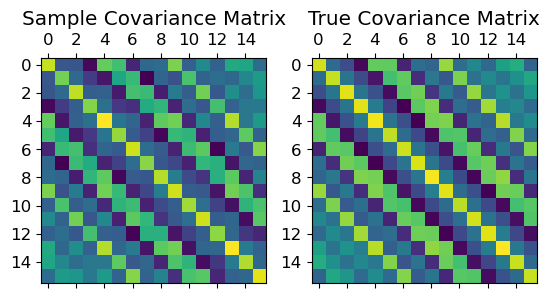

In [14]:
# Received Signal at the Array
X_l = X[:,:100]; 

Rxx_samp_l = (X_l @ hermitian(X_l))/T;                                  # The low-snapshot sample covariance matrix
Rxx_t = (A @ S @ hermitian(A @ S) + noise_pow * np.identity(N))/T;      # The true covariance matrix

# Visualizing low-snapshot sample covariance matrix and the true covariance matrix
fig, (ax1, ax2) = plt.subplots(1,2); 
fig.figsize=(3,3); 
ax1.matshow(np.abs(Rxx_samp_l)); 
ax1.set_title("Sample Covariance Matrix"); 
ax2.matshow(np.abs(Rxx_t)); 
ax2.set_title("True Covariance Matrix"); 
fig.show(); 

print(f"RMSE between Sample Covariance and True Covariance: {np.sqrt(np.mean(np.square(np.abs(Rxx_samp_l - Rxx_t)))):.4f}"); 

We can see that the sample covariance matrix is starting to diverge visually as much as quantitatively. We simply do not have enough samples to approximate $\mathbf{R}_{xx}$ well. In a simulated environment, we can still get on average a good enough signal covariance matrix to work with. This may not always be the case in real life, so MUSIC constrains us to collect as many sample as we can.

In [15]:
# Running the compared algorithms (DAS and MVDR)
P_bartlett_l = doa_est_bartlett(theta_scan, sensor_pos, Rxx_samp_l, wl); 
P_bartlett_dB_l = 10*np.log10(np.abs(np.multiply(P_bartlett_l/np.amax(P_bartlett_l), np.conjugate(P_bartlett_l/np.amax(P_bartlett_l))))); 

P_capon_l = doa_est_capon(theta_scan, sensor_pos, Rxx_samp_l, wl); 
P_capon_dB_l = 10*np.log10(np.abs(np.multiply(P_capon_l/np.amax(P_capon_l), np.conjugate(P_capon_l/np.amax(P_capon_l))))); 

P_music_l = doa_est_music(theta_scan, sensor_pos, Rxx_samp_l, wl, K); 
P_music_dB_l = 10 * np.log10(P_music_l / np.max(P_music_l)); 

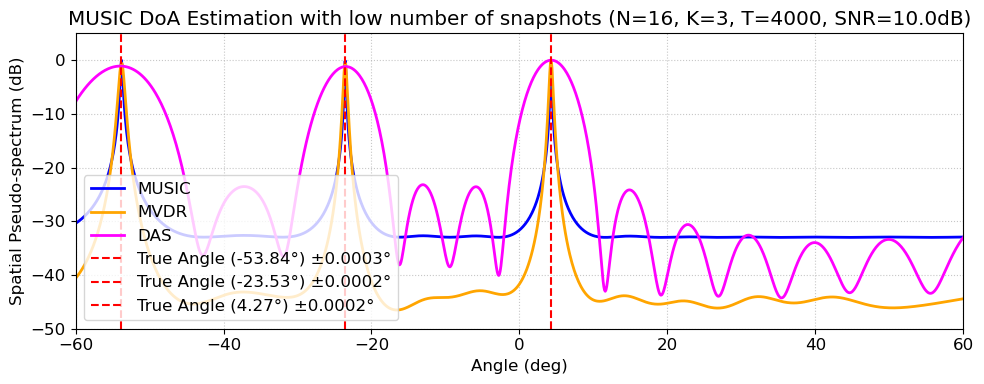

In [16]:
# Visualization
plt.rcParams.update({'font.size': 12}); 

plt.figure(figsize=(10, 4)); 
plt.plot(theta_scan, P_music_dB_l, linewidth=2, color='blue', label='MUSIC'); 
plt.plot(theta_scan, P_capon_dB_l, linewidth=2, color='orange', label='MVDR'); 
plt.plot(theta_scan, P_bartlett_dB_l, linewidth=2, color='magenta', label='DAS'); 

for i, angle in enumerate(true_angles):
    plt.axvline(x=angle, color='red', linestyle='--',
                label=f'True Angle ({angle:.2f}°) ±{CRB_rmse[i]:.4f}°'); 

plt.title(f'MUSIC DoA Estimation with low number of snapshots (N={N}, K={K}, T={T}, SNR={snr_db}dB)'); 
plt.xlabel('Angle (deg)'); 
plt.ylabel('Spatial Pseudo-spectrum (dB)'); 
plt.xlim([ang_min, ang_max]); 
plt.ylim([-50, 5]); 
plt.grid(True, linestyle=':', alpha=0.7); 

handles, labels = plt.gca().get_legend_handles_labels(); 
by_label = dict(zip(labels, handles)); 
plt.legend(by_label.values(), by_label.keys(), loc="lower left"); 

plt.tight_layout(); 
plt.show(); 

Ah, now we have a case where MUSIC is actually not performing any better at suppressing. In fact, MVDR gives us a better spectrum than MUSIC.

### MUSIC with Rician Fading and Correlated Targets
Let's switch the gear and try to see how a different scenario effects the performance, namely targets with correlation. We will now recall the Rician fading model, which incorporates multipath fading with Normal distribution with a LoS target as true sinusoid. While the phases of each target sinusoid are still Uniform rvs, they still have a high chance of correlation. 

We will choose the Rician Rician K-factor ($K_{R}$) at $30\text{ dB}$, meaning that we have a direct LoS signal that is 20-times stronger than the multipath component.

RMSE between Sample Covariance and True Covariance: 0.0273


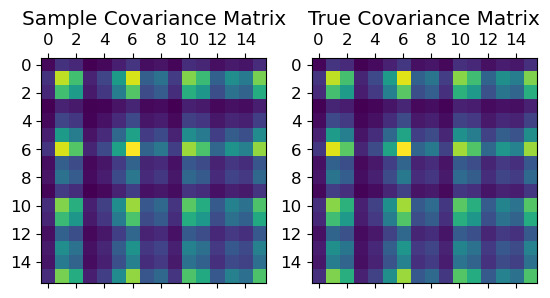

In [29]:
# Rician Fading Target Generation
K_r_db = 30; 
K_r_lin = 10**(K_r_db/10); 

los_amp = np.sqrt(K_r_lin/(K_r_lin + 1)); 
nlos_amp = np.sqrt(1 / (K_r_lin + 1)); 

phase = np.random.uniform(0, 2*np.pi, size=(K));    # Assuming random phase
S_los = np.column_stack([np.exp(1j*2*np.pi*f_c * np.arange(0,(T-1)/f_s,1/f_s)) * np.exp(1j * phase[k]) for k in range(K)]).T; 
S_nlos = (np.random.randn(K, T) + 1j * np.random.randn(K, T)) / np.sqrt(2); 
S_rician = los_amp * S_los + nlos_amp * S_nlos; 

Sr = S_amp @ S_rician;                              # Final target matrix

Hr = np.sqrt(noise_pow) * (np.random.randn(N,T) + 1j*np.random.randn(N,T))/np.sqrt(2); 

Xr = A @ Sr + Hr; 

Rxx_samp_rc = (Xr @ hermitian(Xr))/T;                                   # The low-snapshot sample covariance matrix
Rxx_t = (A @ Sr @ hermitian(A @ Sr) + noise_pow * np.identity(N))/T;    # The true covariance matrix

# Visualizing low-snapshot sample covariance matrix and the true covariance matrix
fig, (ax1, ax2) = plt.subplots(1,2); 
fig.figsize=(3,3); 
ax1.matshow(np.abs(Rxx_samp_rc)); 
ax1.set_title("Sample Covariance Matrix"); 
ax2.matshow(np.abs(Rxx_t)); 
ax2.set_title("True Covariance Matrix"); 
fig.show(); 

print(f"RMSE between Sample Covariance and True Covariance: {np.sqrt(np.mean(np.square(np.abs(Rxx_samp_rc - Rxx_t)))):.4f}"); 

In [30]:
# Running the algorithms for Rician fading targets
P_bartlett_rc = doa_est_bartlett(theta_scan, sensor_pos, Rxx_samp_rc, wl); 
P_bartlett_dB_rc = 10*np.log10(np.abs(np.multiply(P_bartlett_rc/np.amax(P_bartlett_rc), np.conjugate(P_bartlett_rc/np.amax(P_bartlett_rc))))); 

P_capon_rc = doa_est_capon(theta_scan, sensor_pos, Rxx_samp_rc, wl); 
P_capon_dB_rc = 10*np.log10(np.abs(np.multiply(P_capon_rc/np.amax(P_capon_rc), np.conjugate(P_capon_rc/np.amax(P_capon_rc))))); 

P_music_rc = doa_est_music(theta_scan, sensor_pos, Rxx_samp_rc, wl, K); 
P_music_dB_rc = 10 * np.log10(P_music_rc / np.max(P_music_rc)); 

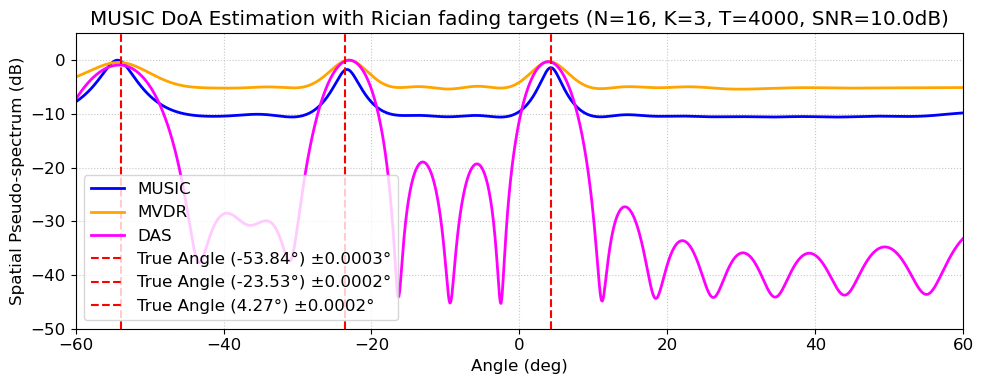

In [31]:
# Visualization
plt.rcParams.update({'font.size': 12}); 

plt.figure(figsize=(10, 4)); 
plt.plot(theta_scan, P_music_dB_rc, linewidth=2, color='blue', label='MUSIC'); 
plt.plot(theta_scan, P_capon_dB_rc, linewidth=2, color='orange', label='MVDR'); 
plt.plot(theta_scan, P_bartlett_dB_rc, linewidth=2, color='magenta', label='DAS'); 

for i, angle in enumerate(true_angles):
    plt.axvline(x=angle, color='red', linestyle='--',
                label=f'True Angle ({angle:.2f}°) ±{CRB_rmse[i]:.4f}°'); 

plt.title(f'MUSIC DoA Estimation with Rician fading targets (N={N}, K={K}, T={T}, SNR={snr_db}dB)'); 
plt.xlabel('Angle (deg)'); 
plt.ylabel('Spatial Pseudo-spectrum (dB)'); 
plt.xlim([ang_min, ang_max]); 
plt.ylim([-50, 5]); 
plt.grid(True, linestyle=':', alpha=0.7); 

handles, labels = plt.gca().get_legend_handles_labels(); 
by_label = dict(zip(labels, handles)); 
plt.legend(by_label.values(), by_label.keys(), loc="lower left"); 

plt.tight_layout(); 
plt.show(); 

Again, the result of MUSIC deteriorated, but this time along with MVDR! How come? Well, remember that all algorithms we discussed so far depend on the orthogonality of the targets. Rician fading breaks this assumption; our targets are not completely uncorrelated. An even worse case will happen if you have much more coherent targets; you can clearly simulate the complete collapse of MVDR and MUSIC if you set the Rician $K$-factor $K_{R}$ to a higher value.

There are several methods to mitigate for the correlated target scenario, like *spatial smoothing* or *hermitian symmetry*. We will dedicate one notebook to the discussion of them once we go through subspace-based DoA estimation methods and right before sparsity-based ones.

## References

[Multiple emitter location and signal parameter estimation](https://ieeexplore.ieee.org/abstract/document/1143830). R. Schmidt. *IEEE Transactions on Antennas and Propagation*. Volume 34. Issue 3. pages 276-280. 31 March 1986.

[Performance study of conditional and unconditional direction-of-arrival estimation](https://ieeexplore.ieee.org/abstract/document/60109?casa_token=BE62pkj8jDYAAAAA:W2_61CPPSG20z0EuJ8G8TWaM1mDmdjCT1XzLJKyOsc8hWclXNTJh_mURHJrPk96wrGtnHRU_ug). P. Stoica and A. Nehorai. *IEEE Transactions on Acoustics, Speech, and Signal Processing*. Volume 38. Issue 10. pages 1783 - 1795. 31 October 1990.